# TRABAJO MATRIZ DE CONFUSIÓN

1) id: identificador único
2) gender: "Hombre", "Mujer" u "Otro"
3) age: edad del paciente
4) hypertension: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca
6) ever_casado: "No" o "Sí"
7) work_type: "niños", "Govt_jov", "Never_worked", "Privado" o "Autónomo"
8) Residence_type: "Rural" o "Urban"
9) avg_glucose_nivel: nivel promedio de glucosa en sangre
10) bmi: índice de masa corporal
11) smoking_status: "anteriormente fumado", "nunca fumado", "humo" o "Desconocido"*
12) stroke: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no
*Nota: "Desconocido" en smoking_status significa que la información no está disponible para este paciente

### LIBRERIAS 

In [353]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

## 1. Carga de datos

In [354]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

## 2. Exploración inicial

In [355]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [356]:
df = df.drop(columns=["id"])

In [357]:
df.shape

(5110, 11)

In [358]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [359]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
Name: stroke, dtype: float64

In [360]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 3. Limpieza de los datos

In [361]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [362]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [363]:
df.dropna(inplace=True)

In [364]:
df.isna().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [365]:
df.shape

(4909, 11)

## 4. Selección de variables

In [366]:
df = pd.get_dummies(df,dtype=int)

In [367]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                               0.232331
hypertension                      0.142515
avg_glucose_level                 0.138936
heart_disease                     0.137938
ever_married_Yes                  0.105089
ever_married_No                   0.105089
work_type_children                0.080971
smoking_status_Unknown            0.075016
smoking_status_formerly smoked    0.057320
work_type_Self-employed           0.055356
bmi                               0.042374
smoking_status_smokes             0.021530
work_type_Private                 0.014934
work_type_Never_worked            0.014149
smoking_status_never smoked       0.010723
gender_Male                       0.006939
gender_Female                     0.006851
Residence_type_Rural              0.006031
Residence_type_Urban              0.006031
work_type_Govt_job                0.003553
gender_Other                      0.003010
Name: stroke, dtype: float64

In [368]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.0,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [369]:
df.shape

(4909, 22)

In [370]:
df['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

## 5. Definicion de X e y

In [371]:
X = df.drop(["stroke"],axis=1)
y = df["stroke"]

In [372]:
print(X.shape)
print(y.shape)

(4909, 21)
(4909,)


## 6. Escalado

In [373]:
# Guardamos el nombre de las variables 
feature_names = df.drop("stroke", axis=1).columns

In [374]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [375]:
print("Primeros registros de X escalada:")
print(X[:5, :3])

Primeros registros de X escalada:
[[ 1.07013796 -0.31806673  4.38196829]
 [ 1.64656262 -0.31806673  4.38196829]
 [ 0.27201152 -0.31806673 -0.22820795]
 [ 1.60222226  3.14399438 -0.22820795]
 [ 1.69090297 -0.31806673 -0.22820795]]


## 7. Train/Test split

In [376]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (3927, 21)
X_test:  (982, 21)
y_train: (3927,)
y_test:  (982,)


## 8. Entrenamiento de modelos de clasificación

### LogisticRegression sin "class_weight='balanced'"

In [377]:
model_lr = LogisticRegression(max_iter=1000) 
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [378]:
y_pred_lr = model_lr.predict(X_test)
print(accuracy_score(y_test, y_pred_lr))

0.9572301425661914


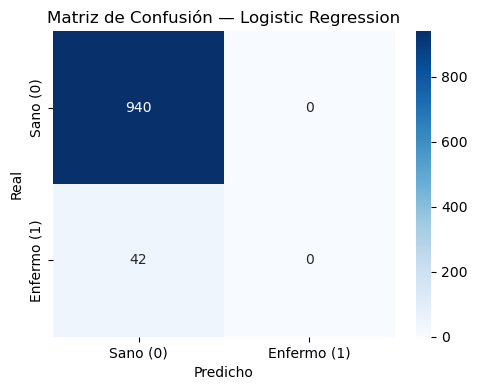

0.9572301425661914


In [379]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr))

### LogisticRegression con "class_weight='balanced'"

In [380]:
model_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced') 
model_lr_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [381]:
y_pred_lr_balanced = model_lr_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_lr_balanced))

0.7566191446028513


In [382]:
# Stratified K-Fold divide los datos en partes, cada una con proporciones similares de cada clase
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    model_lr_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = model_lr_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.745417515274949, 0.7688391038696538, 0.7372708757637475, 0.7087576374745418, 0.7553516819571865]
Accuracy media: 0.7431273628680157


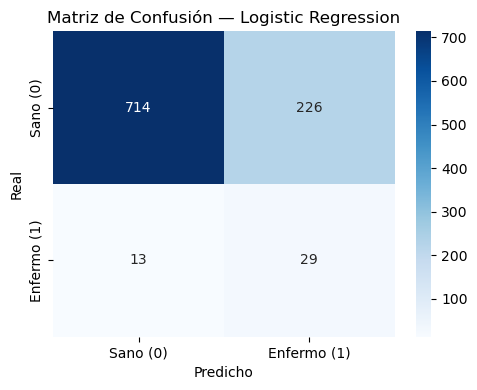

0.7566191446028513


In [383]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr_balanced)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_lr_balanced))

### RandomForestClassifier sin "class_weight='balanced'"

In [384]:
rf_clf = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)

In [385]:
y_pred_rf = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

0.9541751527494908


In [386]:
importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

for feature, importance in importances.items():
    print(f"{feature}: {importance:.4f}")

avg_glucose_level: 0.2630
age: 0.2321
bmi: 0.2259
hypertension: 0.0335
heart_disease: 0.0251
smoking_status_never smoked: 0.0207
Residence_type_Urban: 0.0206
work_type_Private: 0.0198
gender_Male: 0.0194
Residence_type_Rural: 0.0192
gender_Female: 0.0190
work_type_Self-employed: 0.0180
smoking_status_formerly smoked: 0.0178
smoking_status_smokes: 0.0171
smoking_status_Unknown: 0.0139
work_type_Govt_job: 0.0134
ever_married_Yes: 0.0104
ever_married_No: 0.0102
work_type_children: 0.0010
work_type_Never_worked: 0.0000
gender_Other: 0.0000


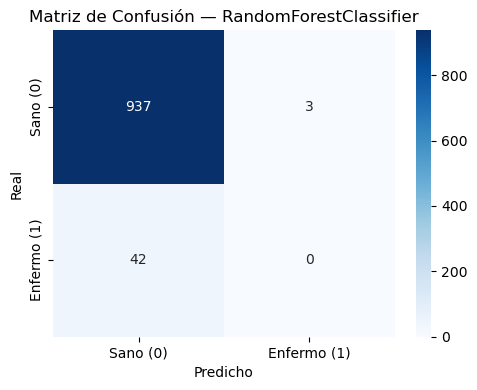

0.9541751527494908


In [387]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf))

### RandomForestClassifier con "class_weight='balanced'"

In [388]:
rf_clf_balanced = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42, class_weight="balanced")
rf_clf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=600, n_jobs=1,
                       random_state=42)

In [389]:
y_pred_rf_balanced = rf_clf_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_rf_balanced))

0.9562118126272913


In [390]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_skf = X
y_skf = y

for train_index, test_index in skf.split(X_skf, y_skf):
    X_train_skf, X_test_skf = X_skf[train_index], X_skf[test_index]
    y_train_skf, y_test_skf = y_skf.iloc[train_index], y_skf.iloc[test_index]

    rf_clf_balanced.fit(X_train_skf, y_train_skf)
    y_pred_skf = rf_clf_balanced.predict(X_test_skf)

    acc = accuracy_score(y_test_skf, y_pred_skf)
    scores.append(acc)

print("Accuracy por fold:", scores)
print("Accuracy media:", np.mean(scores))

Accuracy por fold: [0.9572301425661914, 0.9582484725050916, 0.9531568228105907, 0.9562118126272913, 0.9571865443425076]
Accuracy media: 0.9564067589703346


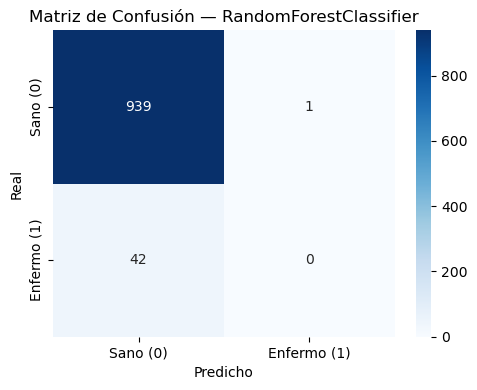

0.9562118126272913


In [391]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf_balanced)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — RandomForestClassifier")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
print(accuracy_score(y_test, y_pred_rf_balanced))

### ROC ACCURACY

In [392]:
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score
)

models = {
    "Logistic Regression": model_lr,
    "Logistic Regression Balanced": model_lr_balanced,
    "Random Forest": rf_clf,
    "Random Forest Balanced": rf_clf_balanced
}

f1_scores = []
precision_scores = []
recall_scores = []
roc_auc_scores = []
accuracy_scores = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # probabilidades para ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)

    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)
    roc_auc_scores.append(roc_auc)
    accuracy_scores.append(accuracy)

    print(f"\n{name}")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"F1-score:    {f1:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"ROC-AUC:     {roc_auc:.4f}")


Logistic Regression
Accuracy:    0.9572
F1-score:    0.0000
Precision:   0.0000
Recall:      0.0000
ROC-AUC:     0.8136

Logistic Regression Balanced
Accuracy:    0.7566
F1-score:    0.1953
Precision:   0.1137
Recall:      0.6905
ROC-AUC:     0.8104

Random Forest
Accuracy:    0.9542
F1-score:    0.0000
Precision:   0.0000
Recall:      0.0000
ROC-AUC:     0.7423

Random Forest Balanced
Accuracy:    0.9562
F1-score:    0.0000
Precision:   0.0000
Recall:      0.0000
ROC-AUC:     0.7576
